In [1]:
import os
os.chdir('D:\yahel\phd\Collaboration\Lenveberg\Hagit\data')
os.getcwd()

'D:\\yahel\\phd\\Collaboration\\Lenveberg\\Hagit\\data'

In [2]:
import csv
import re
import copy
import numpy as np
import pandas as pd
import random
import warnings

from scipy.stats import uniform, randint, ttest_ind , mannwhitneyu, zscore

import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multitest import multipletests, fdrcorrection
from statsmodels.stats.multicomp import MultiComparison


from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.base import BaseEstimator, TransformerMixin

from scipy.cluster.hierarchy import linkage, dendrogram

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.cm import get_cmap
from matplotlib import rcParams

import gseapy as gp
from gseapy.plot import gseaplot, gseaplot2

from venn import venn

import seaborn as sns

from adjustText import adjust_text

import pickle

%reload_ext autoreload
%autoreload 2
%aimport
plt.style.use('default')
%matplotlib inline


Modules to reload:
all-except-skipped

Modules to skip:



In [3]:
# Imputer for normal distribution  with an offset by ouu choice

class OffsetNormalImputer(BaseEstimator, TransformerMixin):
    def __init__(self, std_offset=1.75,seed=None):
        """
        Initializes the imputer with the specified standard deviation offset.
        
        Parameters:
        std_offset: float
            The number of standard deviations to offset the mean for the imputation distribution.
            
        seed : int, optional
            The seed for the random number generator to ensure reproducibility.
        """
        
        self.std_offset = std_offset
        self.seed = seed
        self.combined_mean_ = None
        self.combined_std_ = None

    def fit(self, X, y=None):
        """Compute the mean and std of the data, excluding NaNs."""
        
        # Assuming X is a 2D numpy array or a pandas DataFrame
        self.combined_mean_ = np.nanmean(X.values.flatten())
        self.combined_std_ = np.nanstd(X.values.flatten())
        return self

    def transform(self, X, y=None):
        """Fill in missing values with random samples from the specified normal distribution."""
        if self.combined_mean_ is None or self.combined_std_ is None:
            raise RuntimeError("The imputer has not been fitted yet.")

        np.random.seed(self.seed)  # Set the seed
        
        # Calculate the new mean for the offset distribution
        offset_mean = self.combined_mean_ - self.std_offset * self.combined_std_

        # For each missing value in X, fill in with a random value from the offset normal distribution
        X_transformed = X.applymap(lambda x: np.random.normal(offset_mean, self.combined_std_) 
                                   if pd.isnull(x) else x)
        return X_transformed

    def fit_transform(self, X, y=None, **fit_params):
        return self.fit(X, y).transform(X)

In [4]:
### define a function that tests if gene/protein exists in a certine genotype ###
## assumes that the columns of the matrix are grouped by genotype
## resturns an indexed series of genes/proteins and the genotypes in which they are unique
# GE - a series of expression/level values of a gene/protein
# genotypes - genotypes (by columns order)
# n_repeats - number of repeats in each genotype
# existance - threshold to define existance 
def unique_gene(GE,genotypes,n_repeats = 3, existance = 2):
    valid_values = pd.Series([sum(~GE[range(s,s+n_repeats)].isna()) >= existance for s in range(0,len(GE),n_repeats)],index=genotypes)
    filter_existance = valid_values.sum() > 0
    #if sum(valid_values >= existance) == 1:
    return(filter_existance)

In [5]:
### a function that runs a GSEA for different sets of genes ###
### return a dictionary of dataframes of the terms and their enrhichmant ###
## data - DF with 3 coulmns (4 if combined it true); 
    # name of GENEs as gene name
    # signifiance (p-value/FDR)
    # Measuremnt of intensity and directionality (e.g FC)
    # the pairs compared (releveant only if combined == True)
## significance - string, name of column of significance
## scaler - string, name of column of measurment
## names - string, name of column of gene names
## compare - string, name of column of paired comparisons
## referece - string,name og group to combine by and use as reference
## list_of_sets - list of strings, the gene sets to test for enrichment
## test_group - string, name of the group to test (relevent only of combind == True)
## combined - Boolean, if True than run the analysis on genes chnaged across different comparisons (defaults to False)
## sign_thresh = float, the signifiance threshold for both enrichmnet analysis and filtration of genes (defualts to 0.05)
## scaler_thresh = integer, absolute value of measurement therhold for filtration of genes (defualts to 1)
## **kwargs

def enrichmant_analysis(data:pd.DataFrame ,names,significance, scaler,list_of_sets,
                        compare = False,referece = False, n_comapre = 3,
                        combined = False, sign_thresh = 0.05,
                        scaler_thresh = 1, **kwargs):
    
    """   
    
    
    """
    from gseapy.plot import gseaplot
    import gseapy as gp
    import numpy as np
    import warnings
    
    # get only significant proteins above |FC| = 1
    filtered_mat = data[((data[scaler] >= scaler_thresh) | (data[scaler] <= -scaler_thresh)) & (data[significance] <= sign_thresh)] 
    
    print('There are %i proteins in the GESEA analysis' %filtered_mat.shape[0])
    
    if combined:
        
        # switch the direction of measuremnt if comparisons are flipped since negative values are UPREGULATED
        
        pairs= filtered_mat[compare].unique().tolist()
        for pair in pairs:
            if pd.Series(pair.split('_'))[1] == referece:
                flip_indexes = filtered_mat.index[filtered_mat[compare] == pair]
                filtered_mat.loc[flip_indexes,scaler] = -filtered_mat.loc[flip_indexes,scaler]
                filtered_mat.loc[flip_indexes,compare] = '_'.join(pd.Series(pair.split('_'))[::-1])
        
        
        ## get only signifiacnt proteins shared across all comparisons ##
        
        # check if there are proteins shared across all 3 compraisons
        repeated_counts = pd.Series([sum(filtered_mat[names].isin([i])) for i in filtered_mat[names].unique()])
        
        if sum(repeated_counts >= n_comapre) < 5:
            print('Less than 5 shared proteins across comparisons')
            return('')
        else:
            shared_proteins = filtered_mat[names].unique()[repeated_counts >= n_comapre].tolist()
            filtered_mat = filtered_mat[filtered_mat[names].isin(shared_proteins)]
            
            filtered_mat[scaler] = filtered_mat[scaler].astype('float64')

            # check directionality is stable across all comparisons

            cond = pd.Series([(sum(filtered_mat[scaler][filtered_mat[names].isin([i])] <= -scaler_thresh) == n_comapre  or 
                        sum(filtered_mat[scaler][filtered_mat[names].isin([i])] >= scaler_thresh) == n_comapre) 
                          for i in filtered_mat[names].unique()])

            # filter only stable directionality proteins
            stable_changed = filtered_mat[names].unique()[cond]
            filtered_mat = filtered_mat[filtered_mat[names].isin(stable_changed)]
        
            # average across comparison FDR and FC per protein
            grouped_mat = filtered_mat.groupby(names).mean()

            filtered_mat = pd.DataFrame({'Gene' : grouped_mat.index.values,
                                       'Rank' : grouped_mat.apply(lambda x: x[0] * -np.log10(x[1]),axis=1)})

            filtered_mat = filtered_mat.reset_index(drop= True)
            filtered_mat.sort_values(by= 'Rank',ascending=False,inplace=True)
            
            print('%i proteins are shared across comparisons' %filtered_mat.shape[0])
    
    else:
        # rank the proteins based ob FC and FDR
        filtered_mat['Rank'] = (filtered_mat[scaler] * -np.log10(filtered_mat[significance]))
        filtered_mat.sort_values(by= 'Rank',ascending=False,inplace=True)

        # remove unneccesery columns 
        filtered_mat = filtered_mat[[names,'Rank']]
        filtered_mat.rename(columns={names : 'Gene'},inplace=True)

        # convert Ranks to a float64 not an object
        filtered_mat.Rank = filtered_mat.Rank.astype('float64')
        filtered_mat.Gene = filtered_mat.Gene.str.upper()
    
    # run the GSEA
    
    enrichment = {}
    for g_set in list_of_sets:
        try:
            out = []
            pre_res = gp.prerank(rnk = filtered_mat,
                         gene_sets = g_set,
                         seed = 42, permutation_num = 1000,figsize = (12,6),
                         graph_num= 1, min_size = 15,max_size = 500)

            for term in list(pre_res.results):
                out.append([term,
                           pre_res.results[term]['fdr'],
                           pre_res.results[term]['es'],
                           pre_res.results[term]['nes'],
                           g_set])
                out_df = pd.DataFrame(out, columns = ['Term','fdr', 'es', 'nes','set']).sort_values('fdr').reset_index(drop = True)

            if sum(out_df.fdr <= sign_thresh):
                out_df = out_df[out_df.fdr <= 0.05]
                enrichment[g_set] = {'gsea_df' : out_df,
                                    'gsea_obj' : pre_res}
        except Exception as e:
            print(g_set)
            warnings.warn(f"Warning: {e}", RuntimeWarning)
    return(enrichment)

In [6]:
pd.set_option('display.max_columns', None)

EV_path = os.path.join(os.getcwd(),'EV_proteomics','EVs Seq83410-15_88min_480Ex1-proteins .xlsx')
CM_path = os.path.join(os.getcwd(),'EV_proteomics','Cond. medium Seq83416-21_88min_480Ex1(proteins).xlsx')

EV_mat = pd.read_excel(EV_path,sheet_name='Proteins',index_col=2)
CM_mat = pd.read_excel(CM_path,sheet_name='Proteins',index_col=2)

# remove peptides with less than 2 unique peptides #
EV_mat = EV_mat[EV_mat['# Unique Peptides'] > 1]
CM_mat = CM_mat[CM_mat['# Unique Peptides'] > 1]

EV_mat.head()


,Accession,Description,Exp. q-value: Combined,Protein FDR Confidence: Combined,Sum PEP Score,Coverage [%],# Peptides,# PSMs,# Unique Peptides,# AAs,MW [kDa],calc. pI,Abundances (Normalized): F1: WT 1,Abundances (Normalized): F2: WT 2,Abundances (Normalized): F3: WT 3,Abundances (Normalized): F4: GLUT4 1,Abundances (Normalized): F5: GLUT4,Abundances (Normalized): F6: GLUT4,log 2 Abundances WT 1,log 2 Abundances WT 2,log 2 Abundances WT 3,log 2 Abundances GLUT4 1,log 2 Abundances GLUT4 2,log 2 Abundances GLUT4 3,Found in Sample: [S1] F1: WT 1,Found in Sample: [S2] F2: WT 2,Found in Sample: [S3] F3: WT 3,Found in Sample: [S4] F4: GLUT4 1,Found in Sample: [S5] F5: GLUT4 2,Found in Sample: [S6] F6: GLUT4 3,Score Sequest HT: WT 1,Score Sequest HT: WT 2,Score Sequest HT: WT 3,Score Sequest HT: GLUT4 1,Score Sequest HT: GLUT4 2,Score Sequest HT: GLUT4 3,# Peptides (by Search Engine): WT 1,# Peptides (by Search Engine): WT 2,# Peptides (by Search Engine): WT 3,# Peptides (by Search Engine): GLUT4 1,# Peptides (by Search Engine): GLUT4 2,# Peptides (by Search Engine): GLUT4 3,Biological Process,Cellular Component,Molecular Function,Pfam IDs,Entrez Gene ID,Ensembl Gene ID,Gene ID,Reactome Pathways,WikiPathways,# Protein Pathway Groups,# Razor Peptides,# Protein Groups,Modifications
Gene Symbol,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
CD9,A0A7I2V3T0,Tetraspanin OS=Homo sapiens OX=9606 GN=CD9 PE=...,0,High,6.711,10,2,3,2,216,24.0,5.38,3.963497e+07,4.184885e+07,3.638295e+07,3.358084e+07,2.202700e+07,3.222757e+07,25.240270,25.318685,25.116759,25.001135,24.392770,24.941792,Peak Found,High,Peak Found,High,Peak Found,Peak Found,NaN,1.63,NaN,1.99,NaN,NaN,NaN,2.0,NaN,1.0,NaN,NaN,NaN,other membranes,NaN,Pf00335,NaN,NaN,A0A7I2V3T0,NaN,NaN,0,0,1,NaN
CD81,P60033,CD81 antigen OS=Homo sapiens OX=9606 GN=CD81 P...,0,High,36.515,31,5,16,5,236,25.8,5.29,1.020010e+08,1.166460e+08,8.235997e+07,1.151024e+08,1.134652e+08,1.604171e+08,26.604009,26.797561,26.295440,26.778342,26.757675,27.257253,High,High,High,High,High,High,2.05,13.58,3.70,10.44,6.98,3.73,2.0,4.0,1.0,3.0,3.0,2.0,transport;other biological processes,non-structural extracellular;plasma membrane;o...,signal transduction activity or receptor bindi...,Pf00335,975,ENSG00000110651,hsa:975; P18582; P60033; Q5U0J6,Regulation of Complement cascade; Immunoregula...,B cell receptor signaling pathway; Extracellul...,6,0,1,NaN
CD63,F8VWK8,Tetraspanin (Fragment) OS=Homo sapiens OX=9606...,0,High,6.463,8,2,8,2,217,23.4,7.68,4.712222e+07,4.376817e+07,3.581052e+07,6.447555e+07,5.577915e+07,7.758302e+07,25.489904,25.383379,25.093880,25.942249,25.733223,26.209238,High,High,High,High,High,Peak Found,2.21,3.73,1.68,1.76,2.10,NaN,1.0,2.0,2.0,1.0,1.0,NaN,transport,non-structural extracellular;plasma membrane;o...,NaN,Pf00335,NaN,NaN,F8VWK8,NaN,Extracellular vesicles in the crosstalk of car...,2,0,1,NaN
YWHAZ,P63104,14-3-3 protein zeta/delta OS=Homo sapiens OX=9...,0,High,66.253,53,14,64,11,245,27.7,4.79,4.029610e+08,3.502776e+08,3.301310e+08,2.513158e+08,4.030526e+08,3.438487e+08,28.586065,28.383924,28.298463,27.904926,28.586393,28.357199,High,High,High,High,High,High,21.75,29.31,20.66,22.54,24.45,13.66,10.0,11.0,8.0,10.0,10.0,8.0,cell organization and biogenesis;protein metab...,cytosol;nucleus;other cell component,other molecular function,Pf00244,7534,ENSG00000164924,A8K1N0; B7Z465; hsa:7534; P29213; P29312; P631...,RHO GTPases activate PKNs; Translocation of SL...,Cell cycle; Prolactin signaling pathway; Patho...,23,0,1,Acetyl [N-Term]
YWHAQ,P27348,14-3-3 protein theta OS=Homo sapiens OX=9606 G...,0,High,39.452,37,9,45,6,245,27.7,4.78,5.133020e+07,4.898337e+07,4.427262e+07,4.917346e+07,5.237343e+07,4.305289e+07,25.613305,25.545789,25.399912,25.551377,25.642332,25.359607,High,High,High,High,High,High,18.89,16.37,14.51,14.59,17.59,13.18,9.0,7.0,6.0,5.0,6.0,5.0,transport;signal transduction;other biological...,cytosol;other cell component,other molecular function,Pf00244,10971,ENSG00000134308,D6W4Z5; hsa

In [7]:
# add variant to all duplicates 
EV_mat.index.values[EV_mat.index.duplicated()] = f"variant."+EV_mat.index[EV_mat.index.duplicated()]
CM_mat.index.values[CM_mat.index.duplicated()] = f"variant."+CM_mat.index[CM_mat.index.duplicated()]

# HLA-A had 2 variants in EC data so I changes one to variant 2
EV_mat.index.values[EV_mat.index.duplicated()] = 'variant_2.HLA-A'

# one protein is a novel protein with KOW domain which is a ribosomal protein 
# I decided to assgin in to a ribosomal protein that was not in the data for simplicity

EV_mat.index.values[EV_mat.index.isnull()] = 'RPS7'


In [8]:
# filter just log2  expression
EV_expression_mat = EV_mat.filter(regex='log 2')
CM_expression_mat = CM_mat.filter(regex='log2')

# define group to analysis #
group = [word[3] for word in EV_expression_mat.columns.str.split(' ')]

#filter out proteins with less than 2 repeats in at least 1 group
EV_expression_mat = EV_expression_mat[pd.Series(EV_expression_mat.apply(lambda x: unique_gene(x,['WT', 'GLU4']),axis = 1)).values]
CM_expression_mat = CM_expression_mat[pd.Series(CM_expression_mat.apply(lambda x: unique_gene(x,['WT', 'GLU4']),axis = 1)).values]

EV_expression_mat.head()

,log 2 Abundances WT 1,log 2 Abundances WT 2,log 2 Abundances WT 3,log 2 Abundances GLUT4 1,log 2 Abundances GLUT4 2,log 2 Abundances GLUT4 3
Gene Symbol,,,,,,
CD9,25.240270,25.318685,25.116759,25.001135,24.392770,24.941792
CD81,26.604009,26.797561,26.295440,26.778342,26.757675,27.257253
CD63,25.489904,25.383379,25.093880,25.942249,25.733223,26.209238
YWHAZ,28.586065,28.383924,28.298463,27.904926,28.586393,28.357199
YWHAQ,25.613305,25.545789,25.399912,25.551377,25.642332,25.359607


In [9]:
# number of NA values in each sample 
print('EV missing data column:\n',EV_expression_mat.isnull().sum(axis = 0),
      '\n\n',
      'CM missing data column:\n',CM_expression_mat.isnull().sum(axis = 0))

EV missing data column:
 log 2 Abundances WT 1        2
log 2 Abundances WT 2        1
log 2 Abundances WT 3        1
log 2 Abundances GLUT4 1     0
log 2 Abundances GLUT4 2     0
log 2 Abundances GLUT4 3     1
dtype: int64 

 CM missing data column:
 log2 (abundance) WT 1       2
log2 (abundance) WT 2       1
log2 (abundance) WT 3       1
log2 (abundance) GLUT4 1    1
log2 (abundance) GLUT4 2    1
log2 (abundance) GLUT4 3    0
dtype: int64


In [10]:
# impute missing data using normal ofset imputer class

# instantiate the imputer
imputer  = OffsetNormalImputer(std_offset=3,seed=42)

imputed_EV_mat = None
imputed_CM_mat = None
for cond in pd.Series(group).unique():
    # subset relevent columns per group
    subset_ev , subset_cm = EV_expression_mat.filter(regex=cond), CM_expression_mat.filter(regex=cond)
    
    # imput the data
    imputed_ev = imputer.fit_transform(subset_ev)
    imputed_cm = imputer.fit_transform(subset_cm)
    
    if imputed_EV_mat is None:
        imputed_EV_mat,imputed_CM_mat  = imputed_ev, imputed_cm
    else:
       imputed_EV_mat = imputed_EV_mat.merge(imputed_ev,right_index=True,left_index=True) 
       imputed_CM_mat = imputed_CM_mat.merge(imputed_cm,right_index=True,left_index=True) 

display(imputed_EV_mat)
imputed_CM_mat


,log 2 Abundances WT 1,log 2 Abundances WT 2,log 2 Abundances WT 3,log 2 Abundances GLUT4 1,log 2 Abundances GLUT4 2,log 2 Abundances GLUT4 3
Gene Symbol,,,,,,
CD9,25.240270,25.318685,25.116759,25.001135,24.392770,24.941792
CD81,26.604009,26.797561,26.295440,26.778342,26.757675,27.257253
CD63,25.489904,25.383379,25.093880,25.942249,25.733223,26.209238
YWHAZ,28.586065,28.383924,28.298463,27.904926,28.586393,28.357199
YWHAQ,25.613305,25.545789,25.399912,25.551377,25.642332,25.359607
...,...,...,...,...,...,...
F13A1,28.507181,27.605152,27.783303,27.785851,27.590987,27.996951
IGHA1,22.704189,21.805999,23.473947,21.915494,23.164183,20.419221
PSAP,28.120757,28.646282,28.286522,27.789454,27.400613,27.335491


,log2 (abundance) WT 1,log2 (abundance) WT 2,log2 (abundance) WT 3,log2 (abundance) GLUT4 1,log2 (abundance) GLUT4 2,log2 (abundance) GLUT4 3
Gene Symbol,,,,,,
ALB,36.988165,37.219382,37.147954,37.133943,36.876119,36.834999
KRT1,33.942811,31.927017,33.514010,32.686761,33.918304,34.527553
A2M,33.735532,33.884457,33.803440,33.788397,33.623658,33.540404
HP,33.704730,33.867051,33.905292,33.794678,33.611047,33.512960
APOA1,33.131848,33.318147,33.538037,33.222487,32.975080,33.048263
...,...,...,...,...,...,...
CD248,21.696485,22.148379,21.597458,23.129169,23.190717,22.905064
SERPINH1,20.849843,20.743479,22.694158,22.546825,22.815727,23.292510
BGN,20.752837,20.995396,20.596180,22.447227,22.769244,22.538387


In [31]:
bar_plot_df

,variable,value,Genotype,Marker
0,log 2 Abundances WT 1,25.240270,WT,CD9
1,log 2 Abundances WT 1,26.604009,WT,CD81
2,log 2 Abundances WT 1,25.489904,WT,CD63
3,log 2 Abundances WT 2,25.318685,WT,CD9
4,log 2 Abundances WT 2,26.797561,WT,CD81
5,log 2 Abundances WT 2,25.383379,WT,CD63
6,log 2 Abundances WT 3,25.116759,WT,CD9
7,log 2 Abundances WT 3,26.295440,WT,CD81
8,log 2 Abundances WT 3,25.093880,WT,CD63
9,log 2 Abundances GLUT4 1,25.001135,OEG4,CD9


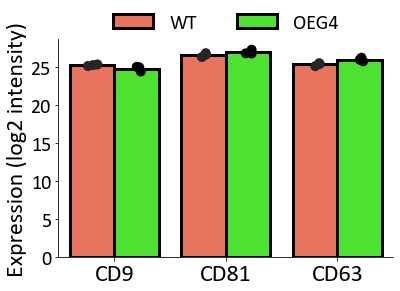

In [78]:
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = 'Calibri'

bar_plot_df = pd.melt(imputed_EV_mat.loc[['CD9','CD81','CD63']])
bar_plot_df['Genotype'] = np.repeat(['WT','OEG4'],9)
bar_plot_df['Marker'] = ['CD9','CD81','CD63'] * 6

sns.barplot(data=bar_plot_df, x='Marker', y='value', hue='Genotype',
            ci='sd',palette = ['tomato','#39FF14'],errcolor = 'black',
            edgecolor='black', linewidth=3)

sns.stripplot(data=bar_plot_df, x='Marker', y='value', hue='Genotype',
              dodge=True, color='black', size=10, jitter=True)

# Remove duplicate legends caused by stripplot
handles, labels = plt.gca().get_legend_handles_labels()
n_groups = len(bar_plot_df['Genotype'].unique())
plt.legend(handles[n_groups:], labels[n_groups:],  # one per Genotype
           loc='lower center', bbox_to_anchor=(0.5, 0.95),
           ncol=n_groups, frameon=False, fontsize=20, title='', title_fontsize=16)


plt.ylabel('Expression (log2 intensity)', fontsize=24)
plt.xlabel('', fontsize=14)
plt.xticks(fontsize=24)
plt.yticks(fontsize=20)

# Remove top and right border lines (spines)
sns.despine(top=True, right=True)




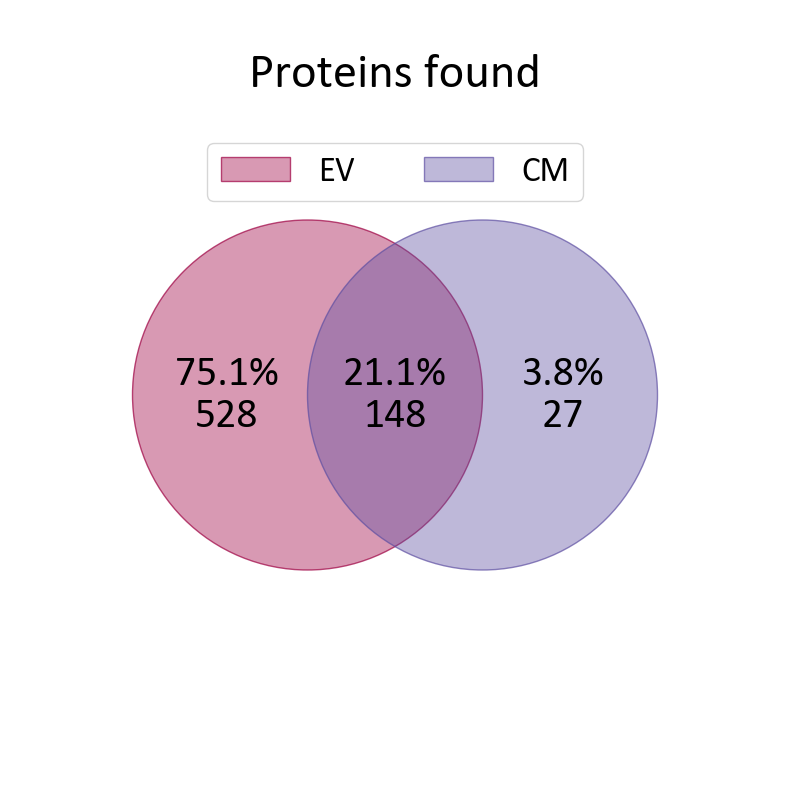

In [12]:
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = 'Calibri'

fig, axes = plt.subplots(1, 1, figsize=(10, 10))

sets_general = {'EV' : set(imputed_EV_mat.index),
                'CM' : set(imputed_CM_mat.index)}

venn(sets_general,fontsize=30,ax = axes,fmt="{percentage:.1f}%\n{size}",cmap = 'Spectral',)
axes.legend(sets_general.keys(),ncol=2, loc='upper center',fontsize = 25,
                 bbox_to_anchor=(0.5, 0.85),bbox_transform=axes.transAxes)
axes.set_title('Proteins found',fontsize = 35,y=0.9, pad=0)

plt.gcf().set_facecolor('white')

## QC for EV

C:\Users\yahelc\AppData\Local\Temp\ipykernel_23760\3690393107.py:24: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = get_cmap('Spectral')
C:\Users\yahelc\AppData\Local\Temp\ipykernel_23760\3690393107.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  QC_proteins_barplot = sns.barplot(data= EV_QC_df,y = 'proteins',x='affiliation',


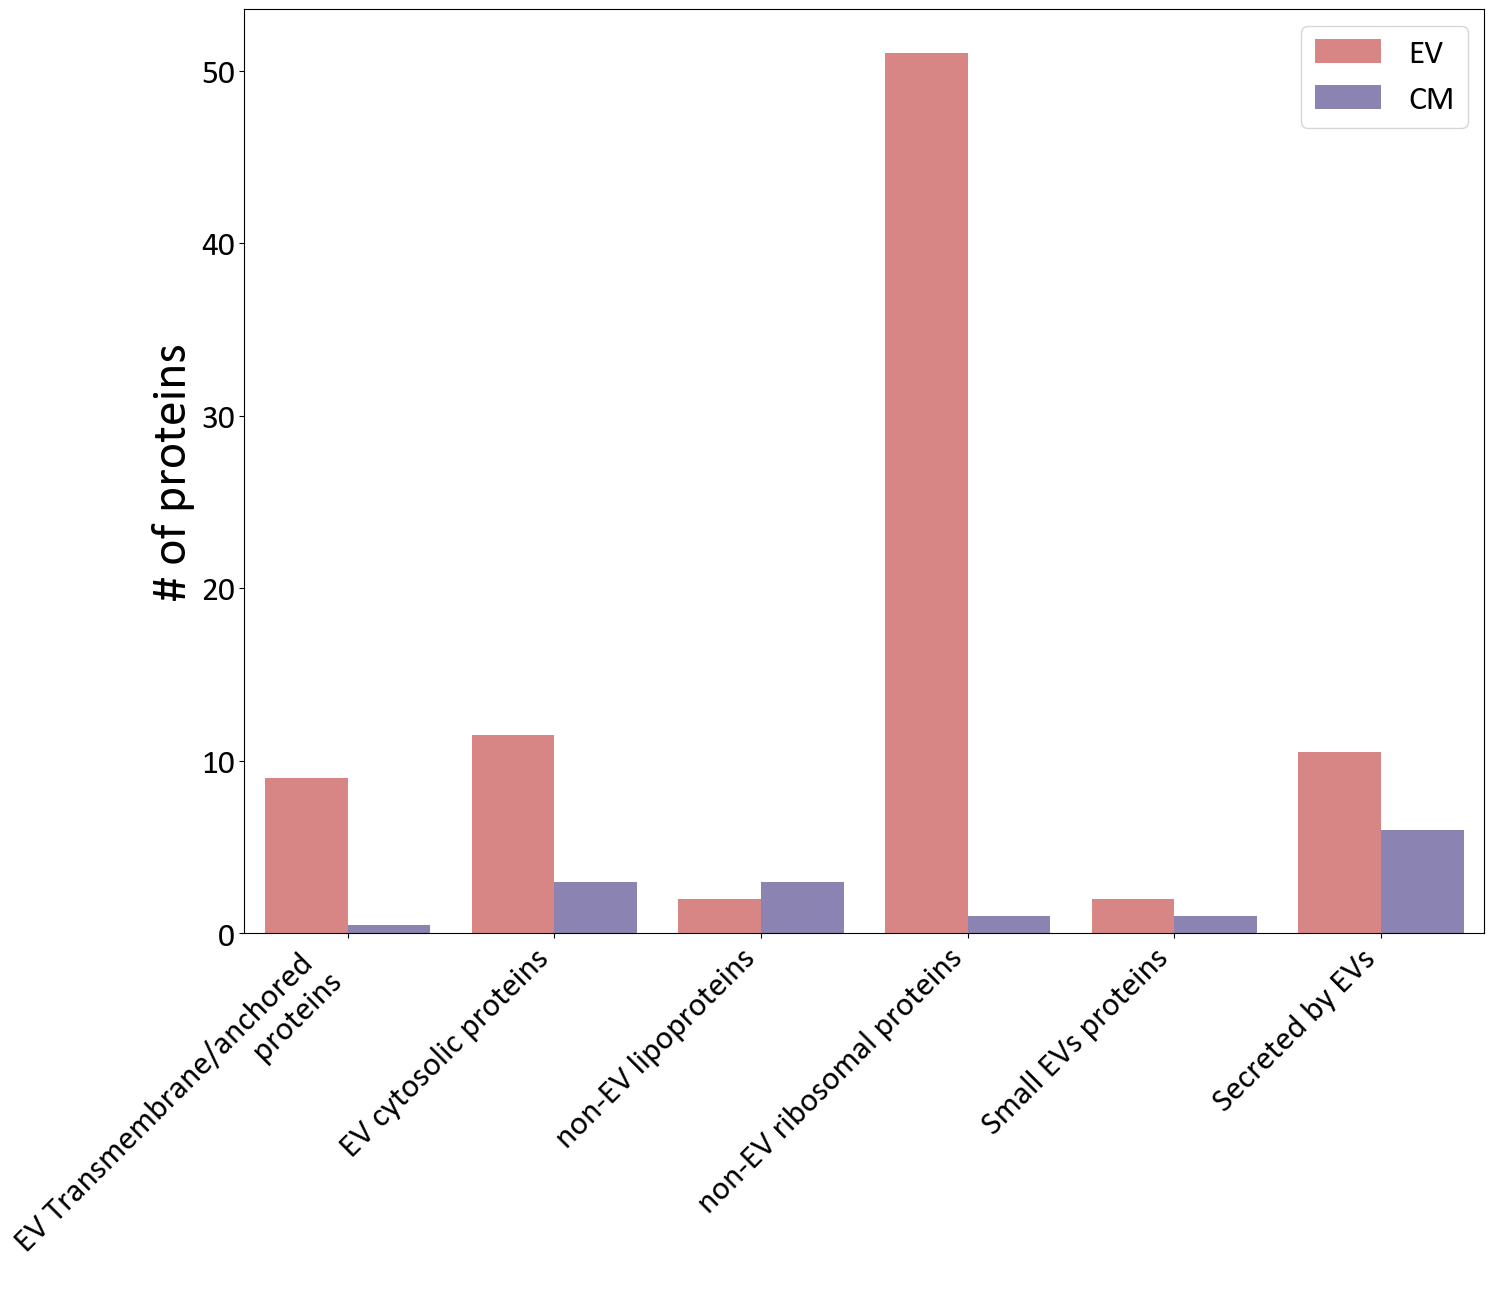

In [13]:
# according the the MISEV 2018 the following must be shown to verify the sample is EVs #
# At least one protein of categories 1a or 1b
# At least one protein of 2a (optionally 2b)
# 3a or 3b must be analysed to demonstrate the EV nature and the degree of purity of an EV preparation
# 4 is required when claiming specific analysis of small EVs
# 5 to document functional activities

EV_protein_standard_path = 'D:\yahel\phd\IPMP - PRIMLS\serum\Proteomics\exoeasy_3rd_proteomics.xlsx'
EV_standard= pd.read_excel(EV_protein_standard_path,sheet_name = 'MISEV 2018 protein groups',header=1)


# append a list of frequancy of each proteins category in each fraction
# filtered by WT only no pertubation! 
EV_cats = []
[EV_cats.append(sum(imputed_EV_mat.filter(regex='GLUT4').index.isin(EV_standard[col]))) for col in EV_standard]
[EV_cats.append(sum(imputed_CM_mat.filter(regex='GLUT4').index.isin(EV_standard[col]))) for col in EV_standard]

# Combine categories 1,2, 4 and 5 together
affiliation = np.repeat(['EV Transmembrane/anchored \n proteins','EV cytosolic proteins',
                         'non-EV lipoproteins','non-EV ribosomal proteins','Small EVs proteins',
                         'Secreted by EVs'], [2,2,1,1,3,2], axis=0)

# specify color pellet
cmap = get_cmap('Spectral')
colors = [cmap(i / 8) for i in range(24)]


EV_QC_df = pd.DataFrame({'Category' : np.repeat([EV_standard.columns],2,axis = 0).flatten(),'proteins' : EV_cats,
                         'affiliation' : np.repeat([affiliation],2,axis = 0).flatten(),
                        'Fraction' : np.repeat(['EV','CM'],[11,11],axis = 0).flatten()})

fig, axes = plt.subplots(1, 1, figsize=(16, 12))
#color = sns.color_palette("rocket")[3]
QC_proteins_barplot = sns.barplot(data= EV_QC_df,y = 'proteins',x='affiliation',
                                  hue = 'Fraction',
                                  ci = None,ax=axes,
                                  palette = [colors[1],colors[14]],
                                 alpha=0.75)

QC_proteins_barplot.set_xticklabels(QC_proteins_barplot.get_xticklabels(), rotation=45,
                                    horizontalalignment='right')
QC_proteins_barplot.set(xlabel=None)
QC_proteins_barplot.tick_params(labelsize=24)
QC_proteins_barplot.set_ylabel("# of proteins",fontsize=36)
QC_proteins_barplot.legend(fontsize = 24)

plt.gcf().set_facecolor('white')

## plot boxplot normelized to stable protein shared across fractions  

In [14]:
# find the most stable expressed protein in two fractions to normalize to
combined_expression_mat = imputed_EV_mat.merge(imputed_CM_mat,how='inner',right_index=True, left_index=True)

combined_expression_mat = combined_expression_mat.filter(regex = 'WT')
combined_expression_mat = combined_expression_mat.T
combined_expression_mat['fraction'] = ['EV', 'EV','EV','CM','CM','CM']

fraction_means = combined_expression_mat.groupby('fraction').mean()
fraction_means = fraction_means.apply(lambda x: abs(x[0]-x[1]),axis = 0)

print(fraction_means.sort_values(ascending=True))
2**fraction_means.sort_values(ascending=True)[0]
# it appears HBB is only different by 0.013 times between the WT CM and EVs

Gene Symbol
HBB        0.018298
QSOX1      0.123516
KRT1       0.126211
IGFBP4     0.126331
B2M        0.175581
             ...   
P4HB       8.588924
LAMB1      8.616023
CD248      9.134112
NID1       9.237952
EMILIN1    9.863163
Length: 148, dtype: float64


1.0127641738487863

In [15]:
# normelize to HBB - filter for only GLUT4
normelized_ev , normelized_cm = imputed_EV_mat.filter(regex='GLUT4') / imputed_EV_mat.filter(regex='GLUT4').loc['HBB'].mean(), \
    imputed_CM_mat.filter(regex='GLUT4') / imputed_CM_mat.filter(regex='GLUT4').loc['HBB'].mean()
    
normelized_cm.head()

,log2 (abundance) GLUT4 1,log2 (abundance) GLUT4 2,log2 (abundance) GLUT4 3
Gene Symbol,,,
ALB,1.423787,1.413901,1.412325
KRT1,1.253273,1.300493,1.323853
A2M,1.295512,1.289196,1.286004
HP,1.295753,1.288712,1.284951
APOA1,1.273814,1.264328,1.267134


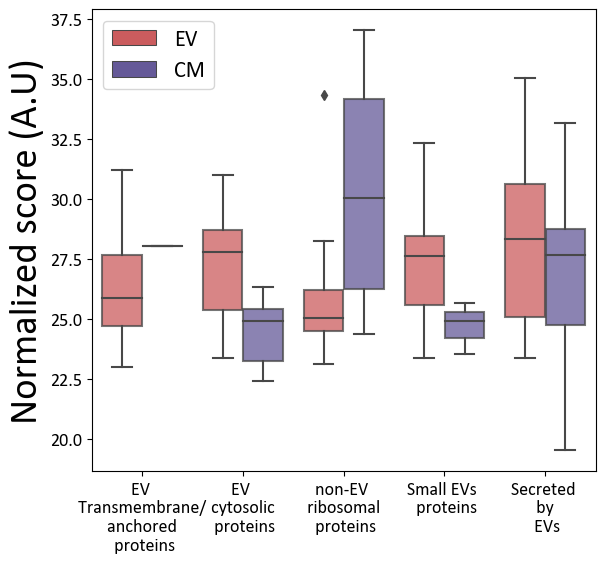

In [32]:
# prepare the dataframe for boxplotting 
from itertools import chain

EV_standard_levels = []
norm_mean_ev = imputed_EV_mat.mean(axis = 1)
[EV_standard_levels.append(norm_mean_ev[norm_mean_ev.index.isin(EV_standard[col])]) for col in EV_standard]

norm_mean_cm = imputed_CM_mat.mean(axis = 1)
[EV_standard_levels.append(norm_mean_cm[norm_mean_cm.index.isin(EV_standard[col])]) for col in EV_standard]

len_category = []
[len_category.append(len(cat)) for cat in EV_standard_levels]
len_fraction = [sum(len_category[:11]), sum(len_category[11:])]

EV_QC_df_ind_levels = pd.DataFrame({'Category' : np.repeat(np.repeat([EV_standard.columns],2,axis = 0).flatten(),len_category,axis = 0).flatten(),
                                    'proteins_level' : list(chain.from_iterable(EV_standard_levels)),
                                    'Fraction' : np.repeat(['EV','CM'],len_fraction,axis = 0).flatten()})

# add a column for affiliation
group_mapping = {
    '1': 'EV \n Transmembrane/ \n anchored \n proteins',
    '2': 'EV \n cytosolic \n proteins',
    '3' : 'non-EV \n ribosomal \n proteins',
    '4' : 'Small EVs \n proteins',
    '5' : 'Secreted \n by \n EVs'
}

EV_QC_df_ind_levels['affiliation'] = EV_QC_df_ind_levels['Category'].str.extract(r'(\d)')[0].replace(group_mapping)

fig, ax = plt.subplots(figsize=(6.5, 6))

QC_proteins_boxplot = sns.boxplot(data= EV_QC_df_ind_levels,y = 'proteins_level',x='affiliation',
                                  hue = 'Fraction',
                                  palette = [colors[1],colors[14]],
                                 boxprops=dict(alpha=.75))


QC_proteins_boxplot.set_xticklabels(QC_proteins_boxplot.get_xticklabels(), rotation=0,
                                    horizontalalignment='center')
QC_proteins_boxplot.set(xlabel=None)
QC_proteins_boxplot.tick_params(labelsize=13)
QC_proteins_boxplot.set_ylabel("Normalized score (A.U)",fontsize=28)
QC_proteins_boxplot.legend(fontsize = 16,loc='upper left')

plt.gcf().set_facecolor('white')

In [40]:
EV_QC_df_ind_levels[EV_QC_df_ind_levels.affiliation == ('EV \n cytosolic \n proteins')].groupby('Fraction').mean()

C:\Users\yahelc\AppData\Local\Temp\ipykernel_23760\3948949205.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  EV_QC_df_ind_levels[EV_QC_df_ind_levels.affiliation == ('EV \n cytosolic \n proteins')].groupby('Fraction').mean()


,proteins_level
Fraction,
CM,24.467738
EV,27.232678


In [38]:
from scipy import stats
t_df = EV_QC_df_ind_levels[EV_QC_df_ind_levels.affiliation == ('EV \n cytosolic \n proteins')]
group_A = t_df[t_df['Fraction'] == 'EV']['proteins_level']
group_B = t_df[t_df['Fraction'] == 'CM']['proteins_level']
stats.ttest_ind(group_A, group_B)

Ttest_indResult(statistic=2.5728907963440157, pvalue=0.015900146354841015)

In [41]:
EV_QC_df_ind_levels[EV_QC_df_ind_levels.affiliation == ('EV \n cytosolic \n proteins')].groupby('Fraction').mean()

C:\Users\yahelc\AppData\Local\Temp\ipykernel_23760\3948949205.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  EV_QC_df_ind_levels[EV_QC_df_ind_levels.affiliation == ('EV \n cytosolic \n proteins')].groupby('Fraction').mean()


,proteins_level
Fraction,
CM,24.467738
EV,27.232678


In [42]:
t_df = EV_QC_df_ind_levels[EV_QC_df_ind_levels.affiliation == ('EV \n cytosolic \n proteins')]
group_A = t_df[t_df['Fraction'] == 'EV']['proteins_level']
group_B = t_df[t_df['Fraction'] == 'CM']['proteins_level']
stats.ttest_ind(group_A, group_B)

Ttest_indResult(statistic=2.5728907963440157, pvalue=0.015900146354841015)

In [43]:
colors[1],colors[14]

((0.8662821991541715, 0.2901191849288735, 0.2978085351787774, 1.0),
 (0.3686274509803922, 0.30980392156862746, 0.6352941176470588, 1.0))

In [44]:
EV_QC_df_ind_levels.to_csv('EVs_qc_boxplot_df_GLUT_log2.csv')

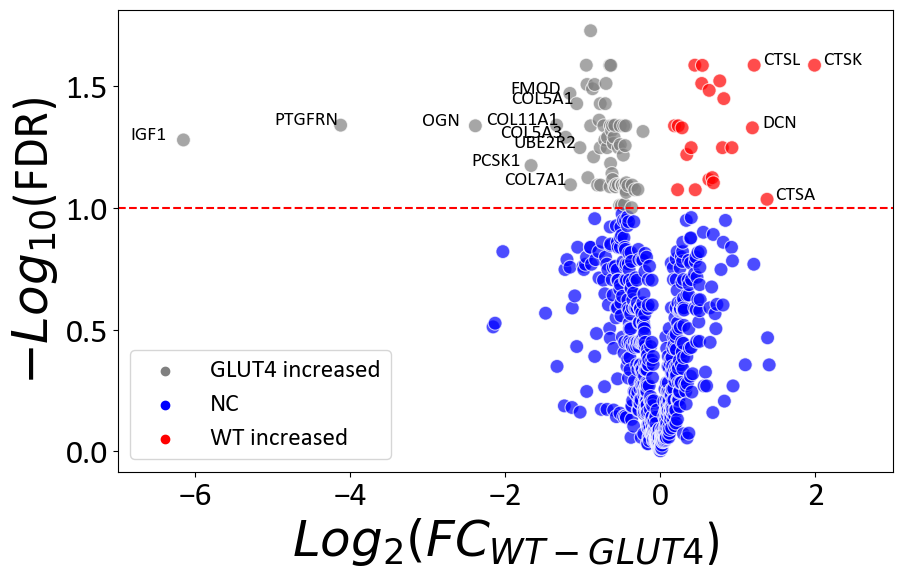

In [47]:
t_test_pvalues = imputed_EV_mat.apply(lambda x: ttest_ind(x[pd.Series(group,index = imputed_EV_mat.columns).isin(['WT'])],
                                         x[pd.Series(group,index = imputed_EV_mat.columns).isin(['GLUT4'])])[1],axis = 1)

fdr_evs =  fdrcorrection(np.array(t_test_pvalues),method='i')[1]

# FC WT-GLUT4
FC_EVs = imputed_EV_mat.T.groupby(group).mean().diff().loc['WT']


volcano_df = pd.DataFrame({'FC' : FC_EVs, 'P-value' : t_test_pvalues, 'FDR' : fdr_evs})

volcano_df.sort_values(by = 'FC', inplace=True)

volcano_df['significant'] = ['WT increased' if (row['FC'] > 0 and row['FDR'] < 0.1) else
              'GLUT4 increased' if (row['FC'] < 0 and row['FDR'] < 0.1) else
              'NC'
              for _, row in volcano_df.iterrows()]

f, ax = plt.subplots(figsize=(10, 6))

custom_palette = ["grey","blue","red"]
sns.set_palette(custom_palette)

# plot upper part
ax = sns.scatterplot(data =volcano_df,
                x = 'FC'
                ,y=-np.log10(volcano_df['FDR']),
                alpha =0.7, s = 100, hue = 'significant',
                palette= custom_palette)

ax.tick_params(labelsize=24)
ax.set_xlabel(r'$Log_2(FC_{WT-GLUT4}$)',fontsize=36)
ax.set_ylabel(r'$-Log_{10}$(FDR)',fontsize=36)
ax.legend(title = None,fontsize = 18)
ax.set_xlim(-7, 3)

plt.axhline(y=-np.log10(0.1), color='red', linestyle='--', label='FDR=0.1')

# Annotate points with |Beta| > 1 and FDR <= 0.05
for _, row in volcano_df.iterrows():
    if row['FC'] < -1 and row['FDR'] <= 0.1:
        ax.annotate(row.name.split(':')[0], (row['FC'], -np.log10(row['FDR'])), fontsize=14, textcoords="offset points", xytext=(-25,0), ha='center')
    if row['FC'] > 1 and row['FDR'] <= 0.1:
        ax.annotate(row.name.split(':')[0], (row['FC'], -np.log10(row['FDR'])), fontsize=14, textcoords="offset points", xytext=(20,0), ha='center')
        
plt.gcf().set_facecolor('white')


## Run GSEA analysis for the proteins with FDR <= 0.1

In [48]:
list_of_sets = ['ClinVar_2019','GO_Biological_Process_2023','GO_Cellular_Component_2023','GO_Molecular_Function_2023',
               'KEGG_2021_Human','Pfam_Domains_2019','ProteomicsDB_2020','Reactome_2022','TargetScan_microRNA']

sig_only_mat = volcano_df.sort_values(by = 'FC')


gsea_mat = pd.DataFrame({'protein' : sig_only_mat.index,
                         'FDR' : sig_only_mat.FDR,
                         'FC' : sig_only_mat.FC})

# adjust FC by -log10 FDR - this does not yeild enrichment 
adjusted_score = gsea_mat.FC * -np.log10(gsea_mat.FDR)
adjusted_score.sort_values(ascending=True,inplace=True)

enrichment = {}
for g_set in list_of_sets:
    try:
        pre_res = gp.prerank(rnk = gsea_mat.FC,
                                gene_sets = g_set,
                                seed = 42, permutation_num = 1000,figsize = (12,6),
                                graph_num= 1, min_size = 15,max_size = 500)
        out = []
        for term in list(pre_res.results):
                    out.append([term,
                            pre_res.results[term]['fdr'],
                            pre_res.results[term]['es'],
                            pre_res.results[term]['nes'],
                            g_set])
                    out_df = pd.DataFrame(out, columns = ['Term','fdr', 'es', 'nes','set']).sort_values('fdr').reset_index(drop = True)
                    
                    if sum(out_df.fdr <= 0.05):
                        out_df = out_df[out_df.fdr <= 0.05]
                        enrichment[g_set] = {'gsea_df' : out_df,
                                            'gsea_obj' : pre_res}
    except Exception as e:
        print(g_set)
        warnings.warn(f"Warning: {e}", RuntimeWarning)

2025-03-26 14:14:24,333 [ERROR] No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.

2025-03-26 14:14:24,333 [ERROR] The first entry of your gene_sets (gmt) look like this : { 4p partial monosomy syndrome: [LETM1, CPLX1, CTBP1, NSD2, WHCR, FGFRL1]}
2025-03-26 14:14:24,333 [ERROR] The first 5 genes look like this : [ CTSK, YBX1, IGFBP6, CTSA, CTSL ]
C:\Users\yahelc\AppData\Local\Temp\ipykernel_23760\1231327427.py:37: RuntimeWarning: Warning: No gene sets passed through filtering condition !!! 
Hint 1: Try to lower min_size or increase max_size !
Hint 2: Check gene symbols are identifiable to your gmt input.
Hint 3: Gene symbols curated in Enrichr web services are all upcases.

  warnings.warn(f"Warning: {e}", RuntimeWarning)


ClinVar_2019


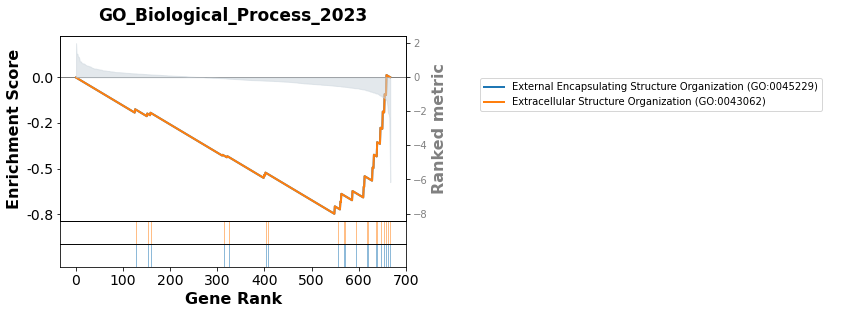

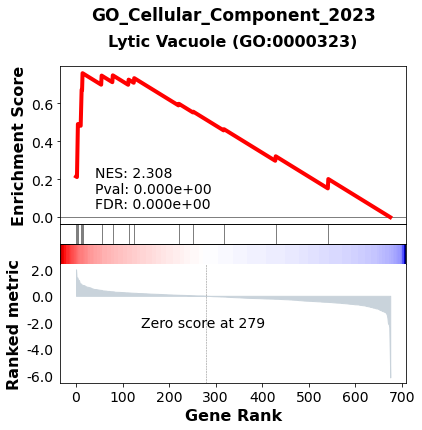

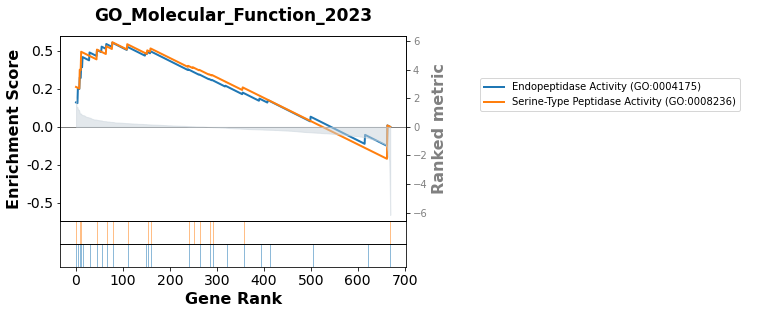

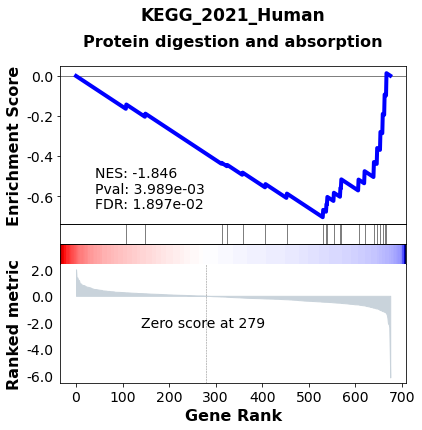

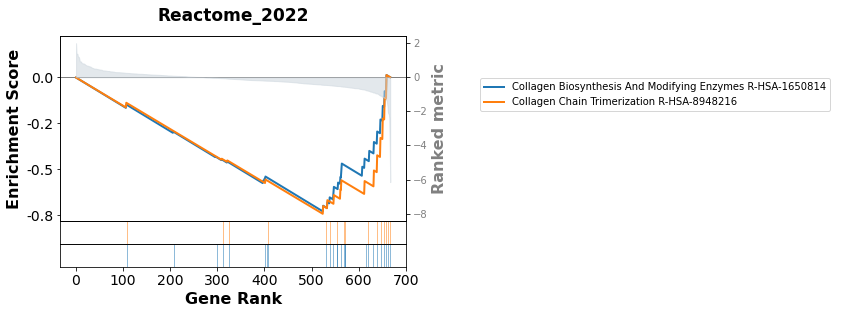

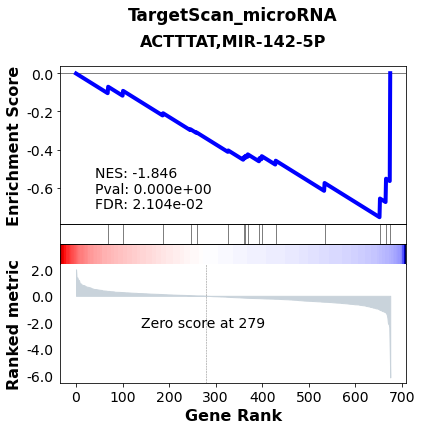

In [491]:
#iterate over the sets of enrhiment
for set_i in enrichment:
    gsea_obj = enrichment[set_i]['gsea_obj']
    gsea_df = enrichment[set_i]['gsea_df']

    # if only one Term is enriched
    if len(gsea_df) == 1:

        if gsea_df.nes.values < 0:
            line_color = 'blue'
        else:
            line_color = 'red'
        
        gseaplot(rank_metric = gsea_obj.ranking, term = gsea_df.Term[0], **gsea_obj.results[gsea_df.Term[0]],color=line_color)
        #plt.suptitle(set_i, weight = 'bold', size = 20, y=1.1)
        plt.title(set_i, fontdict={'weight' : 'bold', 'size' : 17}, y=1.25)

    else:
    # if more than 10 Terms are enriched restricted to 10 and choose top 10 based on |NES|
    # if less thanset the term number to that number
        if len(gsea_df) >= 10:
            max_terms = 10
        else:
            max_terms = len(gsea_df) 

        gsea_df.sort_values(by = 'nes', key = abs, ascending = False, inplace=True)
        gsea_df = gsea_df.iloc[0:max_terms]

        # plot the GSEA

        # get the proteins in in terms and the normelized score per term
        hits =[]
        RES = []
        for term in gsea_df['Term'].tolist():
            hits.append(gsea_obj.results[term]['hits'])
            RES.append(gsea_obj.results[term]['RES'])

        gsea_plot = gseaplot2(rank_metric = gsea_obj.ranking, terms = gsea_df['Term'].tolist(),
                    hits = hits, RESs = RES)
            
        # play with the legend position
        handles_gsea, labels_gsea = gsea_plot[max_terms].get_legend_handles_labels()

        gsea_plot[max_terms].legend(handles = handles_gsea, labels = labels_gsea,
                    bbox_to_anchor=(1.25, 0.9), bbox_transform=ax.transAxes)

        plt.title(set_i, fontdict={'weight' : 'bold', 'size' : 17}, y=1.05)


In [49]:
GLUT_decreased = sig_only_mat.index[(sig_only_mat['FDR'] <= 0.1) & (sig_only_mat['FC'] > 0)].tolist()
GLUT_increased = sig_only_mat.index[(sig_only_mat['FDR'] <= 0.1) & (sig_only_mat['FC'] < 0)].tolist()

enr_down = gp.enrich(gene_list=GLUT_decreased,
            gene_sets=list_of_sets,
            background=None, # or "hsapiens_gene_ensembl", or int, or text file, or a list of genes
            outdir=None,
            verbose=True)

down_enr_sig  = enr_down.results[enr_down.results['Adjusted P-value'] <= 0.05]

enr_up = gp.enrich(gene_list=GLUT_increased, 
            gene_sets=list_of_sets,
            background=None, # or "hsapiens_gene_ensembl", or int, or text file, or a list of genes
            outdir=None,
            verbose=True)

up_enr_sig  = enr_up.results[enr_up.results['Adjusted P-value'] <= 0.05]

2025-03-26 14:14:50,154 [INFO] Run: ClinVar_2019 
2025-03-26 14:14:51,819 [INFO] Run: GO_Biological_Process_2023 
2025-03-26 14:14:53,773 [INFO] Run: GO_Cellular_Component_2023 
2025-03-26 14:14:55,434 [INFO] Run: GO_Molecular_Function_2023 
2025-03-26 14:14:57,158 [INFO] Run: KEGG_2021_Human 
2025-03-26 14:14:58,811 [INFO] Run: Pfam_Domains_2019 
2025-03-26 14:15:00,413 [INFO] Run: ProteomicsDB_2020 
2025-03-26 14:15:02,367 [INFO] Run: Reactome_2022 
2025-03-26 14:15:04,217 [INFO] Run: TargetScan_microRNA 
2025-03-26 14:15:05,929 [INFO] Done.
2025-03-26 14:15:07,083 [INFO] Run: ClinVar_2019 
2025-03-26 14:15:08,829 [INFO] Run: GO_Biological_Process_2023 
2025-03-26 14:15:11,020 [INFO] Run: GO_Cellular_Component_2023 
2025-03-26 14:15:12,958 [INFO] Run: GO_Molecular_Function_2023 
2025-03-26 14:15:14,900 [INFO] Run: KEGG_2021_Human 
2025-03-26 14:15:16,784 [INFO] Run: Pfam_Domains_2019 
2025-03-26 14:15:18,529 [INFO] Run: ProteomicsDB_2020 
2025-03-26 14:15:20,736 [INFO] Run: Reactome_

In [593]:
down_enr_sig.to_csv('GLUT4_enriched_Terms.csv')
up_enr_sig.to_csv('GLUT4_depleted_Terms.csv')
gsea_mat.to_csv('FC_EVs_mat.csv')

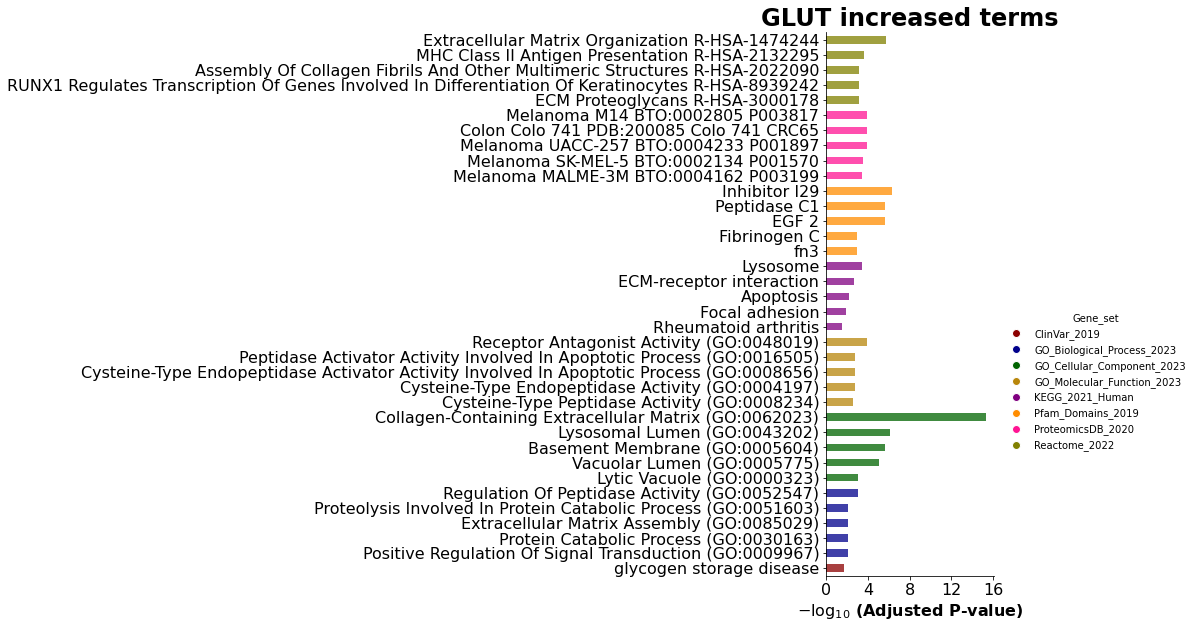

In [594]:
enrich_bar = gp.barplot(down_enr_sig,
        column="Adjusted P-value",
        group='Gene_set', # set group, so you could do a multi-sample/library comparsion
        top_term=5,
        figsize=(3,10),
        title='GLUT increased terms',
        color=['darkred', 'darkblue','darkgreen',
                'darkgoldenrod','purple','darkorange',
                'deeppink','olive','crimson'] # set colors for group
        )

plt.gcf().set_facecolor('white')

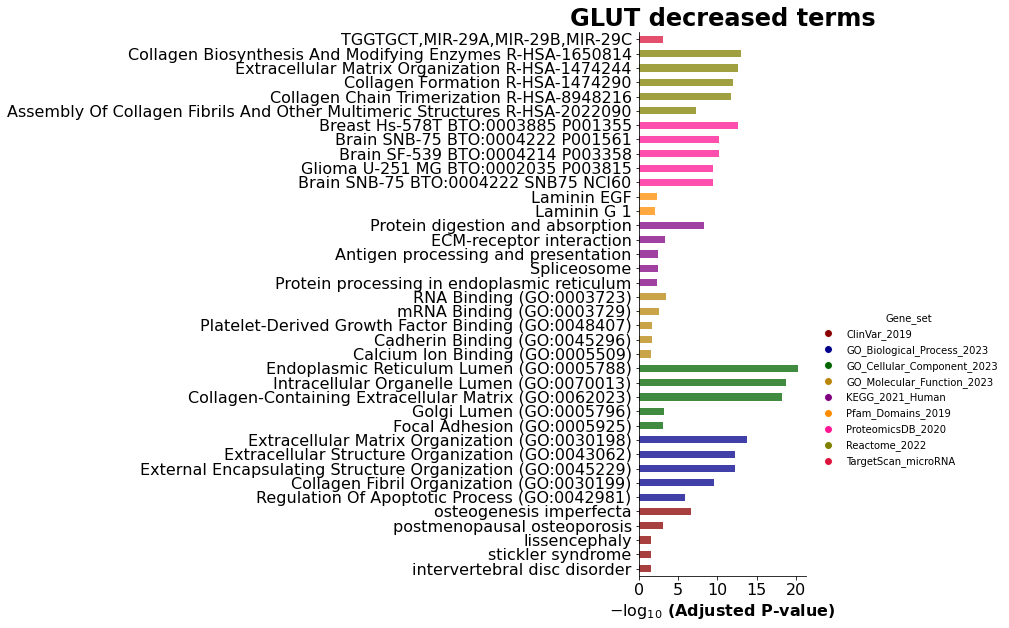

In [595]:
enrich_bar = gp.barplot(up_enr_sig,
        column="Adjusted P-value",
        group='Gene_set', # set group, so you could do a multi-sample/library comparsion
        top_term=5,
        figsize=(3,10),
        title='GLUT decreased terms',
        color=['darkred', 'darkblue','darkgreen',
                'darkgoldenrod','purple','darkorange',
                'deeppink','olive','crimson'] # set colors for group
        )

plt.gcf().set_facecolor('white')

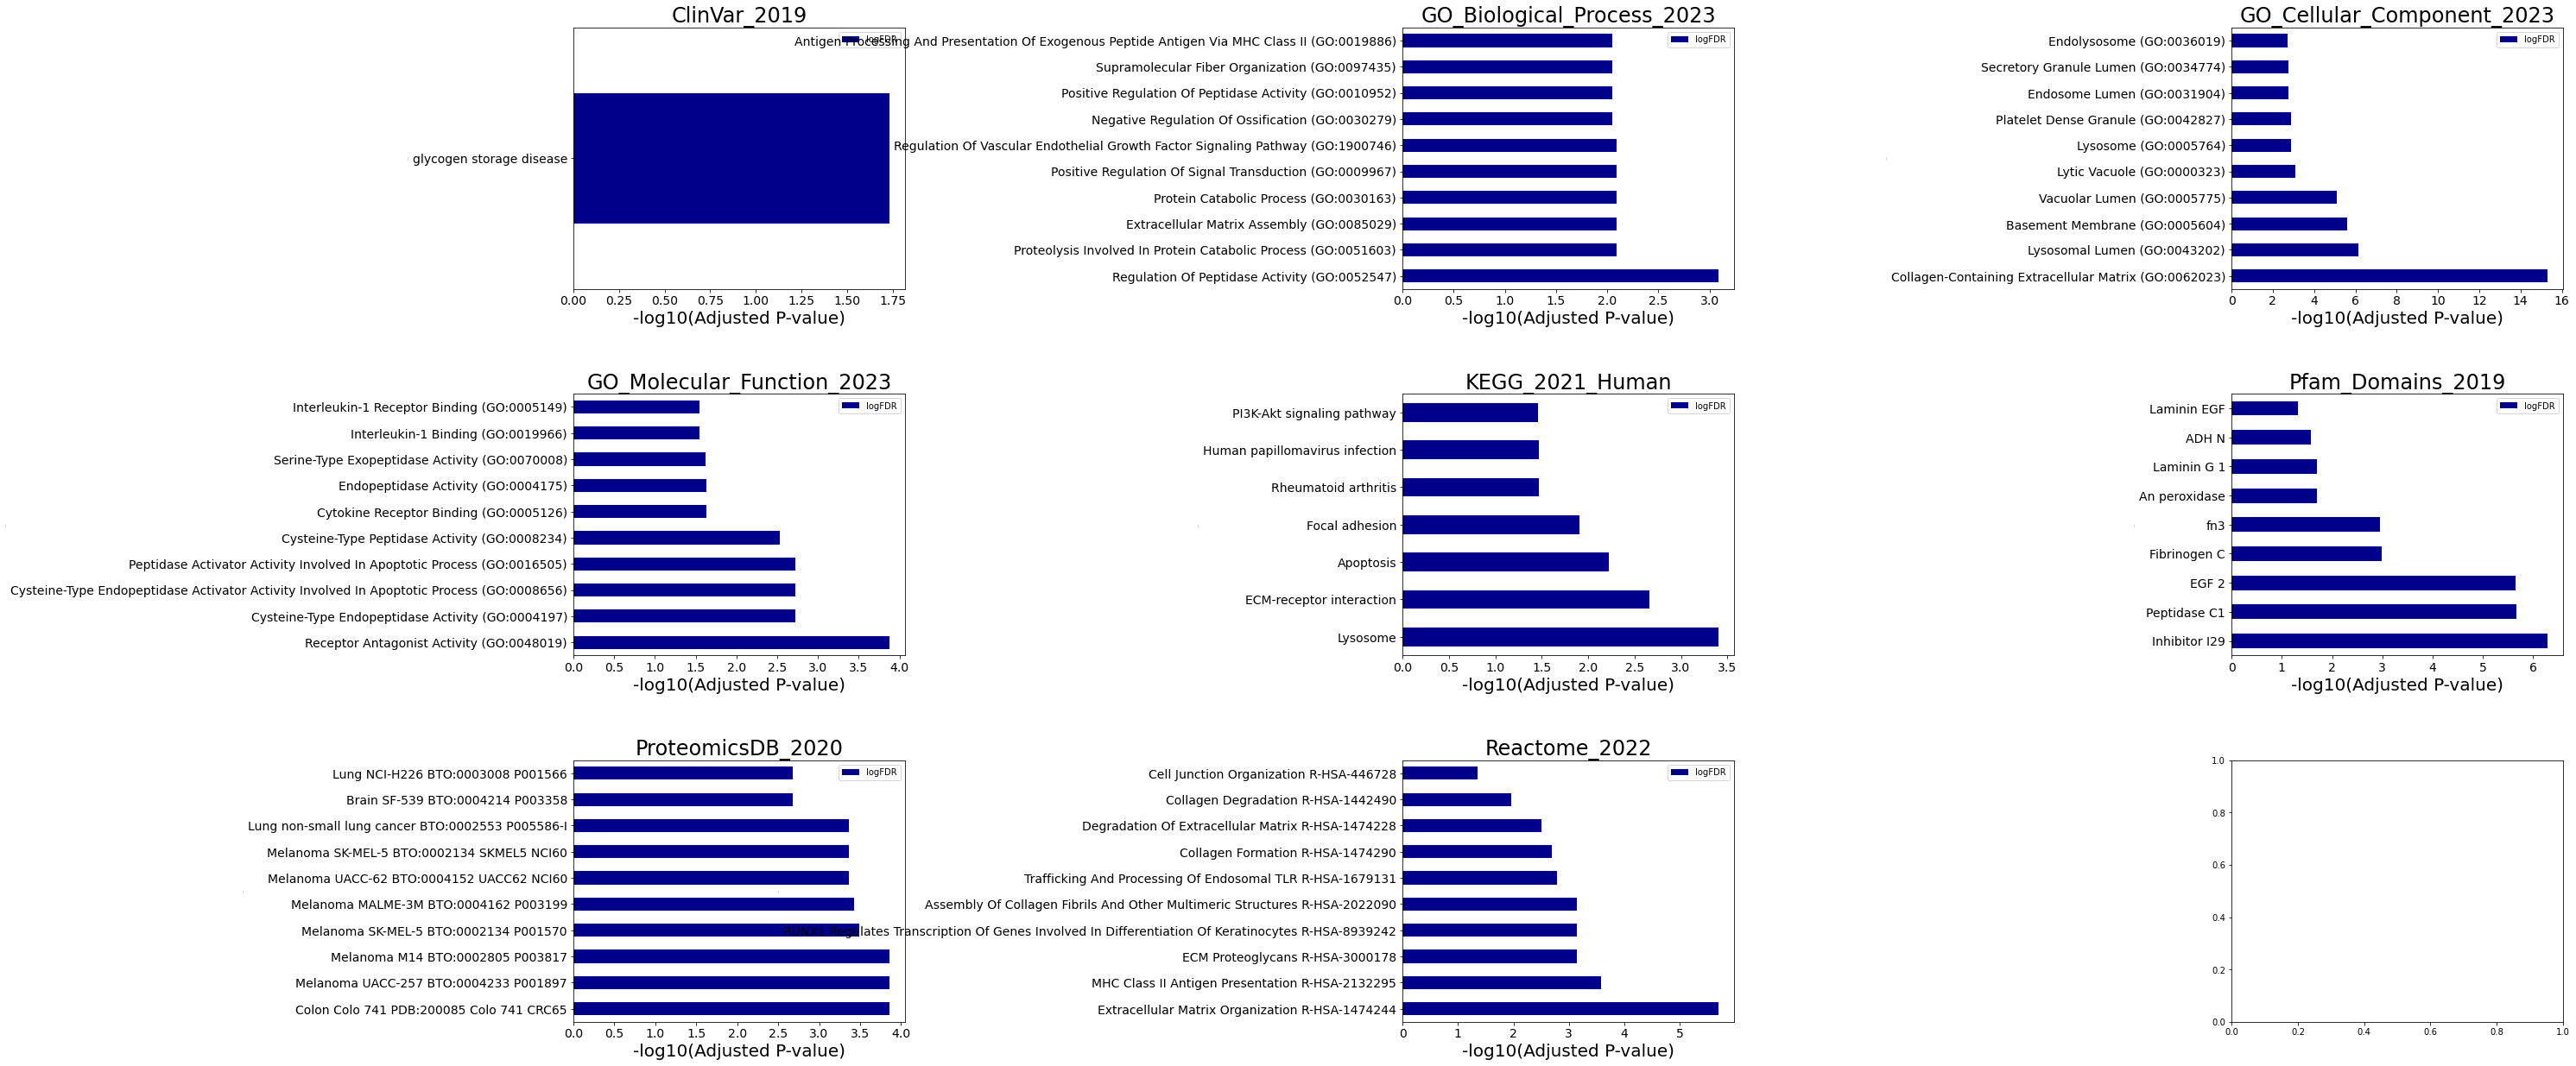

In [582]:
# Set up the matplotlib figure and axes for a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(40, 20))  # Adjust the figsize as needed
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Get unique gene sets
gene_sets = down_enr_sig['Gene_set'].unique()

# Loop through the gene sets and create a barplot for each
for i, gene_set in enumerate(gene_sets):
    # Filter the results for the current gene set
    df_subset = down_enr_sig[down_enr_sig['Gene_set'] == gene_set]
    df_subset = df_subset.head(10)
    df_subset['logFDR'] = -np.log10(df_subset["Adjusted P-value"])

    # Plot on the corresponding subplot
    df_subset.plot.barh(x = "Term", y = 'logFDR', color = 'darkblue',ax = axes[i])
    
    axes[i].set_title(gene_set , fontsize = 24)
        # Set the fontsize for the x and y labels
    axes[i].set_xlabel('-log10(Adjusted P-value)', fontsize=20)
    axes[i].set_ylabel('Terms', fontsize=0)
    
        # Set the fontsize for the tick labels
    axes[i].tick_params(axis='both', which='major', labelsize=14)
    
    plt.gcf().set_facecolor('white')
fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=1.5, hspace=0.4)


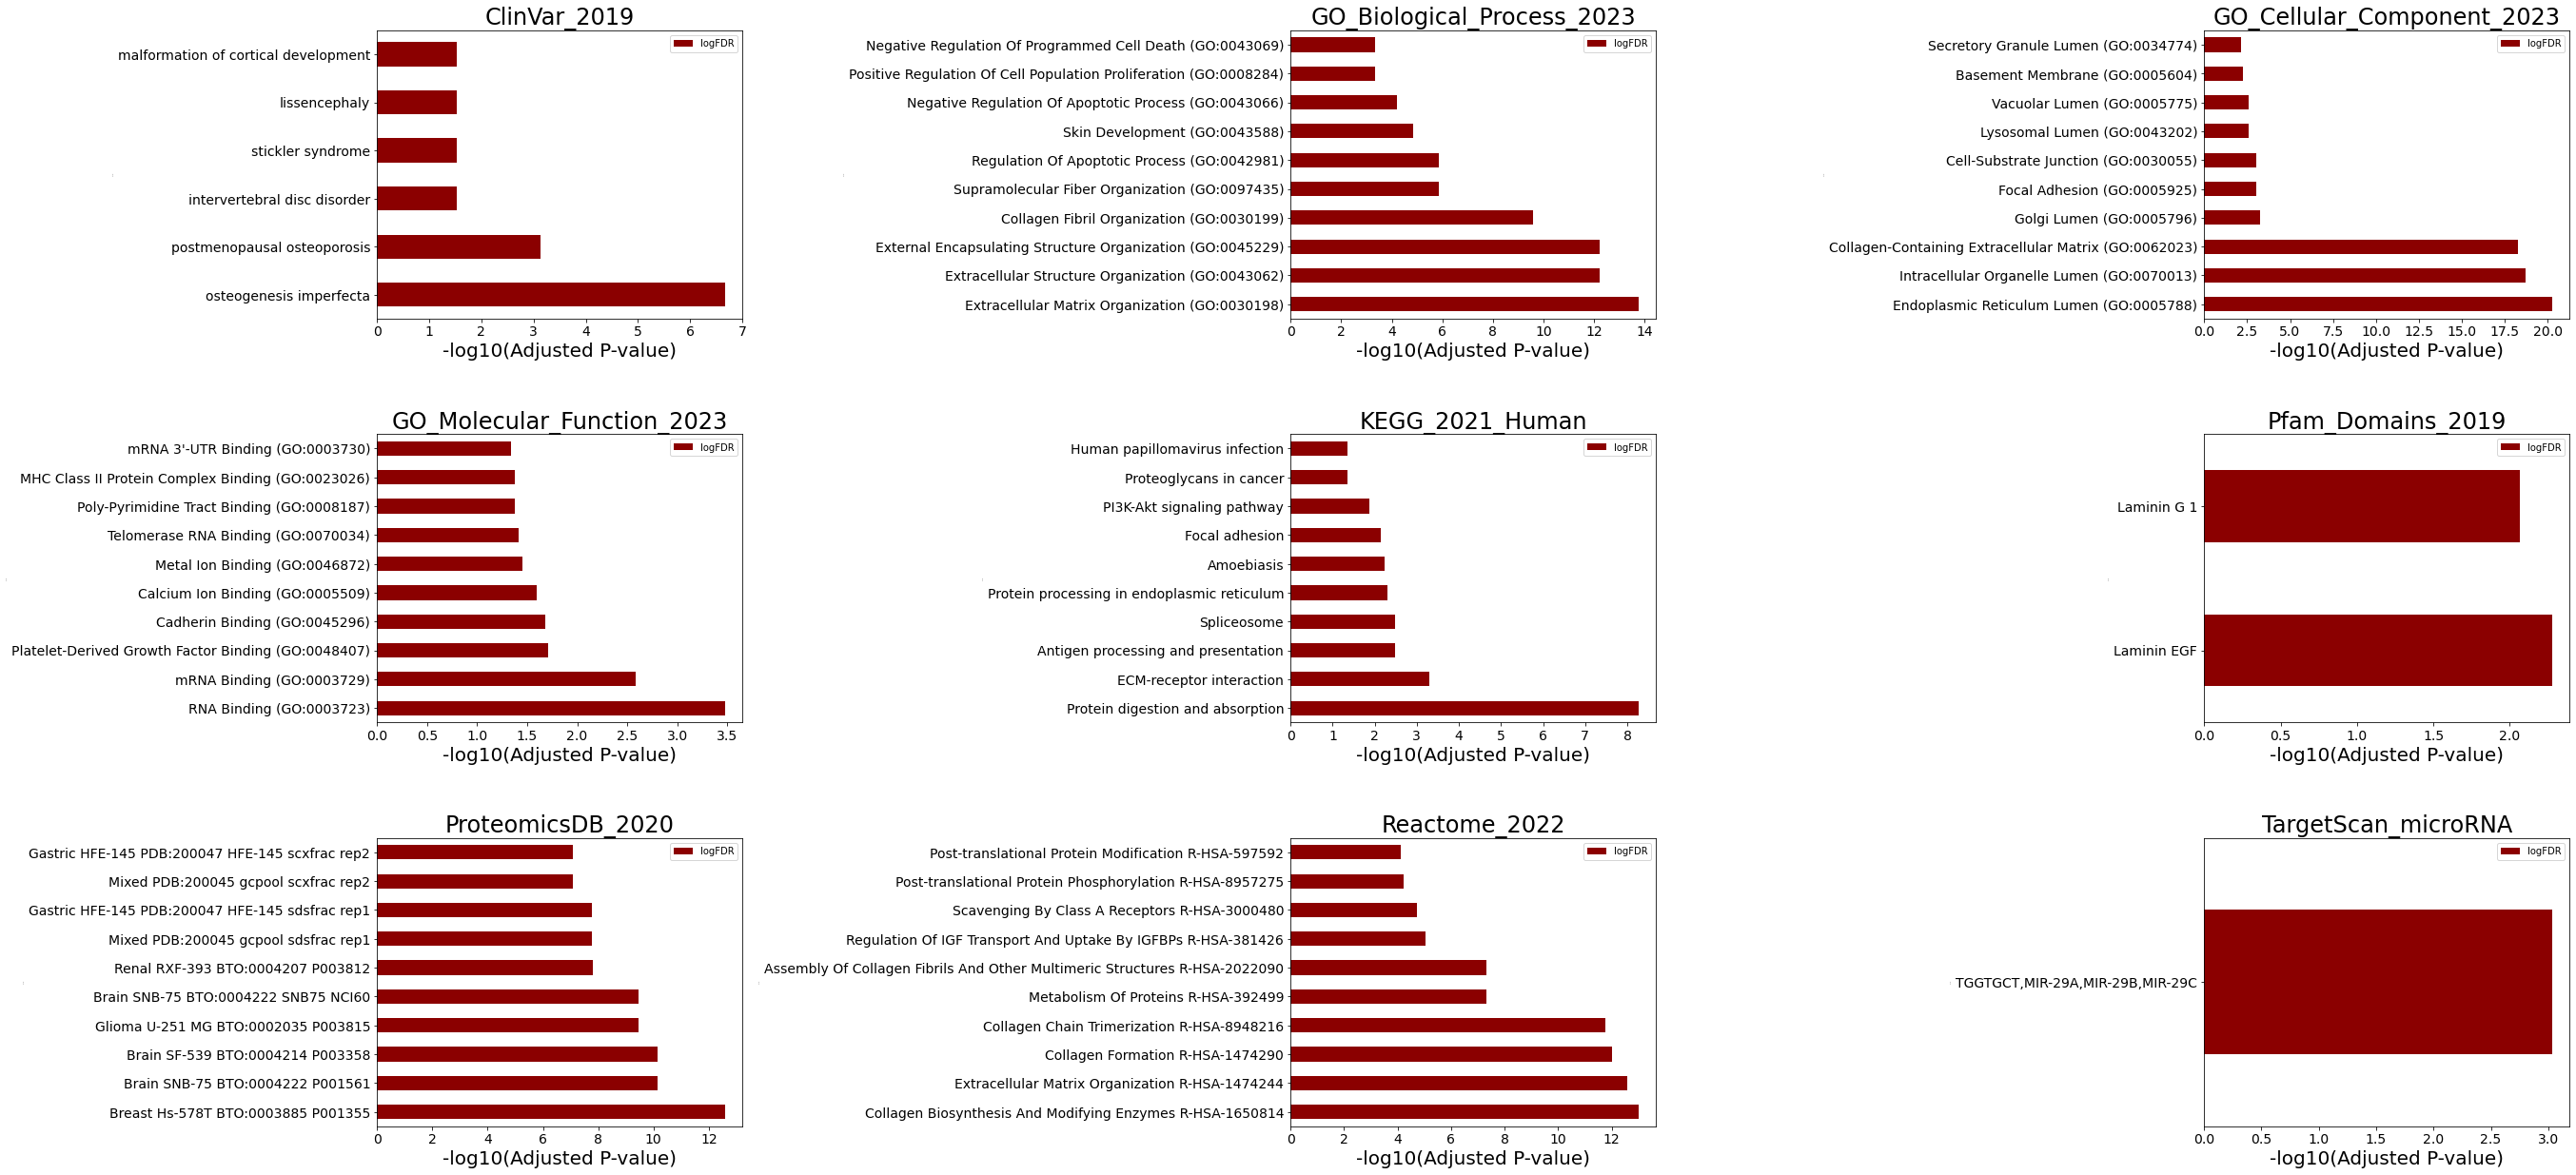

In [584]:
# Set up the matplotlib figure and axes for a 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(40, 20))  # Adjust the figsize as needed
axes = axes.flatten()  # Flatten the 2D array of axes for easy iteration

# Get unique gene sets
gene_sets = up_enr_sig['Gene_set'].unique()

# Loop through the gene sets and create a barplot for each
for i, gene_set in enumerate(gene_sets):
    # Filter the results for the current gene set
    df_subset = up_enr_sig[up_enr_sig['Gene_set'] == gene_set]
    df_subset = df_subset.head(10)
    df_subset['logFDR'] = -np.log10(df_subset["Adjusted P-value"])

    # Plot on the corresponding subplot
    df_subset.plot.barh(x = "Term", y = 'logFDR', color = 'darkred',ax = axes[i])
    
    axes[i].set_title(gene_set , fontsize = 24)
        # Set the fontsize for the x and y labels
    axes[i].set_xlabel('-log10(Adjusted P-value)', fontsize=20)
    axes[i].set_ylabel('Terms', fontsize=0)
    
        # Set the fontsize for the tick labels
    axes[i].tick_params(axis='both', which='major', labelsize=14)
    
    plt.gcf().set_facecolor('white')
fig.subplots_adjust(left=0.1, right=0.9, bottom=0.1, top=0.9, wspace=1.5, hspace=0.4)